In [27]:
!pip install imbalanced-learn
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

In [28]:
try:
    df = pd.read_csv('healthcare-dataset-stroke-data.csv')
except FileNotFoundError:
    print("Download 'healthcare-dataset-stroke-data.csv' from Kaggle.")
    exit()

In [29]:
df.drop('id', axis=1, inplace=True)
df = df[df['gender'] != 'Other']

In [30]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [31]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [32]:
X = df.drop('stroke', axis=1)
y = df['stroke']

# 3. Feature Selection
numeric_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
                        'work_type', 'Residence_type', 'smoking_status']

In [33]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
])

In [34]:
clf1 = LogisticRegression(class_weight='balanced', random_state=42)
clf2 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
clf3 = AdaBoostClassifier(n_estimators=100, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('ada', clf3)],
    voting='soft'
)

In [35]:
clf1 = LogisticRegression(class_weight='balanced', random_state=42)
clf2 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
clf3 = AdaBoostClassifier(n_estimators=100, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('ada', clf3)],
    voting='soft'
)

In [36]:
model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),  # Handles the 5% stroke vs 95% non-stroke split
    ('classifier', voting_clf)
])

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model_pipeline.fit(X_train, y_train)

# 8. Evaluation
y_pred = model_pipeline.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, model_pipeline.predict_proba(X_test)[:, 1]):.4f}")

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.79      0.88       972
           1       0.16      0.76      0.26        50

    accuracy                           0.79      1022
   macro avg       0.57      0.78      0.57      1022
weighted avg       0.94      0.79      0.85      1022

ROC-AUC Score: 0.8272


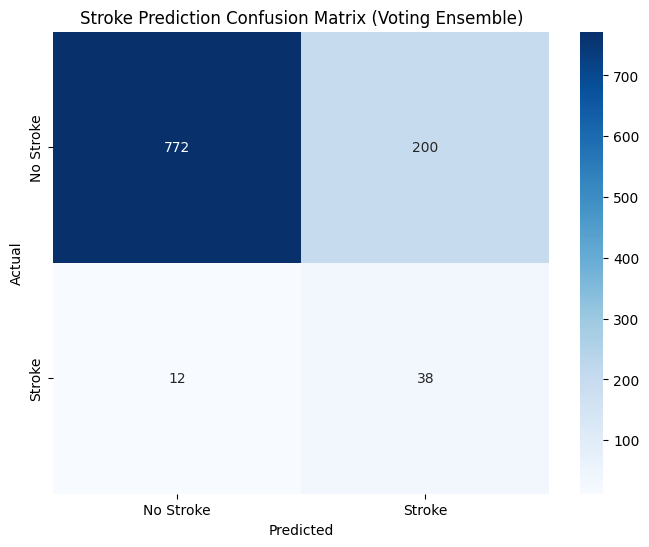

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Stroke', 'Stroke'], 
            yticklabels=['No Stroke', 'Stroke'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Stroke Prediction Confusion Matrix (Voting Ensemble)')
plt.savefig('confusion_matrix.png')
plt.show()